# Self-Organizing Maps

## Importing the libraries

In [18]:
!pip install minisom

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Importing the dataset

In [20]:
dataset = pd.read_csv("Credit_Card_Applications.csv")
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

## Feature Scaling

In [21]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler(feature_range = (0, 1))
X = minmax.fit_transform(X)

## Training the SOM

In [22]:
from minisom import MiniSom
som = MiniSom(x = 10, y = 10, input_len = 15, sigma = 1.0, learning_rate = 0.5)
som.random_weights_init(X)
som.train_random(data = X, num_iteration = 100)

## Visualizing the results

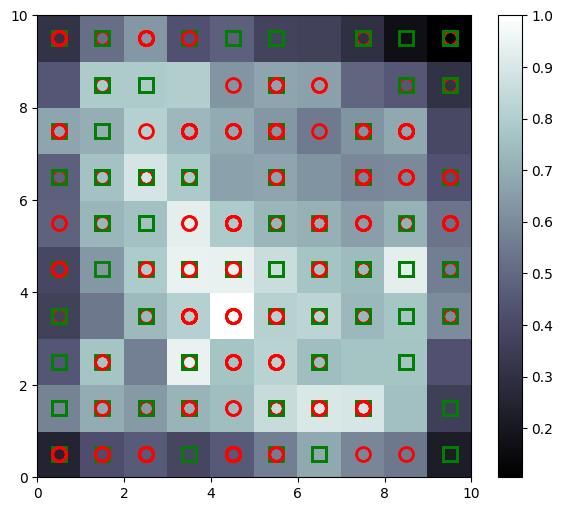

In [23]:
plt.figure(figsize = (7, 6))
plt.bone()

plt.pcolor(som.distance_map().T)
plt.colorbar()

marker = ['o', 's']
color = ['r', 'g']

for i, x in enumerate(X):
  w = som.winner(x)

  plt.plot(
      w[0] + 0.5,
      w[1] + 0.5,
      marker[y[i]],
      markeredgecolor = color[y[i]],
      markerfacecolor = 'None',
      markersize = 10,
      markeredgewidth = 2
  )

plt.show()

## Finding the frauds

In [25]:
mappings = som.win_map(X)
frauds = np.concatenate((mappings[(3, 4)], mappings[(5, 4)]), axis = 0)
frauds = minmax.inverse_transform(frauds)

In [26]:
print('Fraud Customer IDs')
for i in frauds[:, 0]:
  print(int(i))

Fraud Customer IDs
15621546
15636478
15585192
15591552
15611318
15664083
15622507
15640521
15591248
15659031
15571571
15632669
15705343
15671987
15773776
15791769
15776494


## Finding Accuracy using KMeans Clustering

In [27]:
from sklearn.cluster import KMeans

weights = som.get_weights()
grid_x, grid_y = weights.shape[0], weights.shape[1]

flat_weights = weights.reshape(grid_x * grid_y, -1)

kmeans = KMeans(n_clusters = 2, random_state = 42)
neuron_labels = kmeans.fit_predict(flat_weights)

labels = []
for x in X:
    r, c = som.winner(x)
    neuron_index = r * grid_y + c
    labels.append(neuron_labels[neuron_index])

## Graphically Visualizing

In [28]:
df = pd.DataFrame({"Actual": y, "Predicted": labels})
matrix = pd.crosstab(df['Actual'], df['Predicted'])

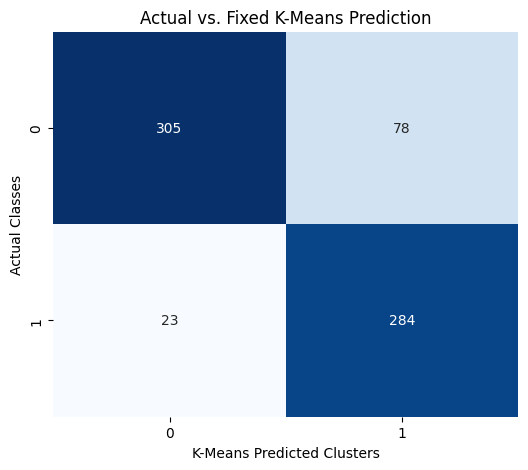

In [29]:
plt.figure(figsize = (6, 5))
sns.heatmap(matrix, annot = True, fmt = 'd', cmap = 'Blues', cbar = False)
plt.xlabel('K-Means Predicted Clusters')
plt.ylabel('Actual Classes')
plt.title('Actual vs. Fixed K-Means Prediction')
plt.show()

In [30]:
df

,Actual,Predicted
0,0,0
1,0,0
2,0,0
3,1,1
4,1,1
...,...,...
685,1,1
686,0,0
687,1,1
688,1,1
